In [2]:
import cv2
import numpy as npD
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

In [ ]:
batch_size = 32
img_height = 224
img_width = 224

In [4]:

training_ds = tf.keras.preprocessing.image_dataset_from_directory(
'data\\train\\',
    image_size= (img_height, img_width),
    batch_size=batch_size)

Found 240 files belonging to 2 classes.


In [5]:
testing_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'data\\test\\',
    image_size= (img_height, img_width),
    batch_size=batch_size)

Found 289 files belonging to 2 classes.


In [6]:
validation_ds =  tf.keras.preprocessing.image_dataset_from_directory(
 'data\\val\\',
    image_size= (img_height, img_width),
    batch_size=batch_size)

Found 98 files belonging to 2 classes.


In [7]:
class_names = training_ds.class_names
print(class_names)

['Accident', 'Non Accident']


In [8]:

AUTOTUNE = tf.data.experimental.AUTOTUNE
training_ds = training_ds.cache().prefetch(buffer_size=AUTOTUNE)
testing_ds = testing_ds.cache().prefetch(buffer_size=AUTOTUNE)

img_shape = (img_height, img_width, 3)

In [9]:
print(img_shape)

(224, 224, 3)


In [9]:
#AI
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# Load pretrained MobileNetV2 without top layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=img_shape)

# Freeze the base model to use pretrained weights
base_model.trainable = False

# Add custom top layers
x = base_model.output
x = GlobalAveragePooling2D()(x)         # Flatten feature maps via average pooling
x = Dropout(0.3)(x)                     # Optional: Reduce overfitting
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)                     # Optional: Reduce overfitting
output = Dense(1, activation='sigmoid')(x)  # Binary classification output

# Final model
model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Summary (optional for debugging)
# model.summary()

In [10]:
# AI
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [11]:
#AI
history = model.fit(training_ds, validation_data = validation_ds, epochs = 10)


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 528ms/step - accuracy: 0.5598 - loss: 0.7399 - val_accuracy: 0.5714 - val_loss: 0.8473
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 360ms/step - accuracy: 0.7143 - loss: 0.5454 - val_accuracy: 0.5816 - val_loss: 0.8796
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 349ms/step - accuracy: 0.7133 - loss: 0.5149 - val_accuracy: 0.6020 - val_loss: 0.7172
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 346ms/step - accuracy: 0.7942 - loss: 0.4209 - val_accuracy: 0.5612 - val_loss: 0.9351
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 358ms/step - accuracy: 0.7869 - loss: 0.4043 - val_accuracy: 0.5714 - val_loss: 0.7577
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 368ms/step - accuracy: 0.8341 - loss: 0.3562 - val_accuracy: 0.5918 - val_loss: 0.8758
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 364ms/step - accuracy: 0.8559 - loss: 0.3209 - val_accuracy: 0.6020 - val_loss: 0.8482
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 356ms/step - accuracy: 0.8676 - loss: 0.2912 - val_accuracy: 0.6020 - val_loss:

In [12]:
#AI
loss, accuracy = model.evaluate(validation_ds)
print(f"✅ Validation Accuracy: {accuracy * 100:.2f}%")

loss, accuracy = model.evaluate(testing_ds)
print(f"✅ Test Accuracy: {accuracy * 100:.2f}%")


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - accuracy: 0.6117 - loss: 0.8630
✅ Validation Accuracy: 59.18%
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 238ms/step - accuracy: 0.6125 - loss: 0.7304
✅ Test Accuracy: 62.63%


In [ ]:
#Ai
model.save("model/AccidentDetectionModel.h5")

In [10]:

base_model = tf.keras.applications.MobileNetV2(input_shape=img_shape,
                                               include_top=False,
                                               weights='imagenet')

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.Conv2D(128, 3, activation='relu'),
    layers.Flatten(),
    layers.Dense(len(class_names), activation= 'sigmoid')
])


In [10]:
print(base_model)

<Functional name=mobilenetv2_1.00_224, built=True>


In [11]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [12]:
history = model.fit(training_ds, validation_data = validation_ds, epochs = 10)


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 15s 803ms/step - accuracy: 0.5672 - loss: 1.1162 - val_accuracy: 0.4694 - val_loss: 1.3346
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 423ms/step - accuracy: 0.6326 - loss: 0.6032 - val_accuracy: 0.5918 - val_loss: 0.8851
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 422ms/step - accuracy: 0.9284 - loss: 0.2762 - val_accuracy: 0.5918 - val_loss: 1.1553
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 417ms/step - accuracy: 0.9086 - loss: 0.2079 - val_accuracy: 0.5816 - val_loss: 1.3199
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 414ms/step - accuracy: 0.9501 - loss: 0.1209 - val_accuracy: 0.5918 - val_loss: 1.3258
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 422ms/step - accuracy: 0.9671 - loss: 0.1081 - val_accuracy: 0.6020 - val_loss: 1.2413
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 436ms/step - accuracy: 0.9972 - loss: 0.0254 - val_accuracy: 0.5816 - val_loss: 1.4683
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 417ms/step - accuracy: 0.9932 - loss: 0.0274 - val_accuracy: 0.5918 - val_loss

In [13]:
loss, accuracy = model.evaluate(validation_ds)
print(f"✅ Validation Accuracy: {accuracy * 100:.2f}%")

loss, accuracy = model.evaluate(testing_ds)
print(f"✅ Test Accuracy: {accuracy * 100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step - accuracy: 0.5774 - loss: 2.2955
✅ Validation Accuracy: 59.18%
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 300ms/step - accuracy: 0.7551 - loss: 1.0452
✅ Test Accuracy: 73.01%


In [14]:
model.save("Accident_Detection_Model_001.h5")

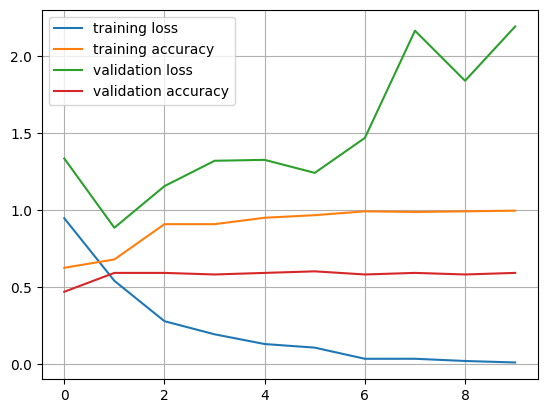

In [15]:
plt.plot(history.history['loss'], label = 'training loss')
plt.plot(history.history['accuracy'], label = 'training accuracy')
plt.grid(True)
plt.legend()


plt.plot(history.history['val_loss'], label = 'validation loss')
plt.plot(history.history['val_accuracy'], label = 'validation accuracy')
plt.grid(True)
plt.legend()

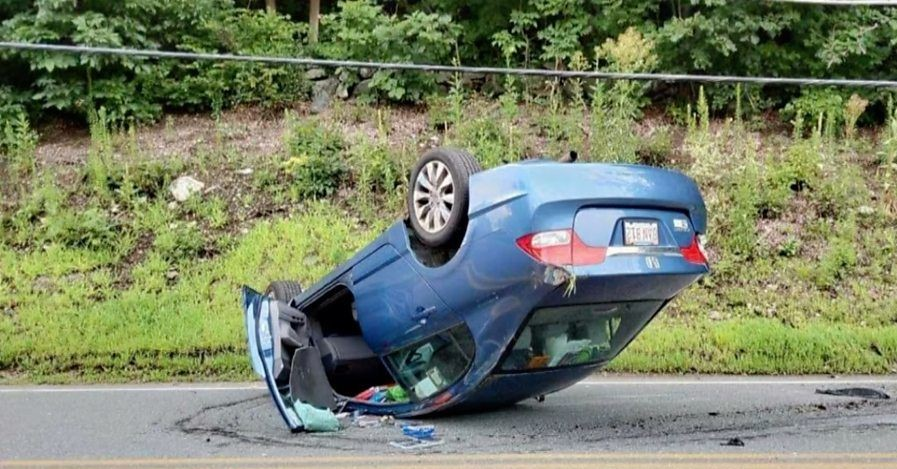

In [16]:
from IPython.display import Image
file_path = r'final\after testing\test1.PNG'
f=r'final/before testing/_108317050_p07kmppq.jpg'
Image(filename=f)


In [17]:
def predict_frame(img):
    img_array = tf.keras.utils.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    #print(img_array)
    #print(img_batch)
    prediction=(model.predict(img_batch) < 0.5).astype("int32")
    print(prediction)
    if(prediction[0][0]==0):
        return("Accident Detected")
    else:
        return("No Accident")


In [18]:
def print_ans(label,image):
  f=0
  for i in label:
    if i=="Accident Detected":
      f=1
  if f:
    print("Accident Detected")
    print(plt.imshow(image[len(image)//2]))
  else:
    print("No Accident Detected")
    print(plt.imshow(image[len(image)//2]))